In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

In [2]:
# Print the names of the features:
print(feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [3]:
# Print a sample of 5 rows
print(X[:5, :])

[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01 2.839e-01 2.414

In [4]:
# The shape of the data
print(X.shape, y.shape)

(569, 30) (569,)


In [5]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
import numpy as np

X_train_scaled = X_train_scaled.T
ones = np.ones((1, X_train_scaled.shape[1]))
X = np.append(ones, X_train_scaled, axis=0)

# Initialize the parameters
learning_rate = 0.1
epochs = 1000

In [ ]:
from matplotlib import pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def logistic_regression(X, y, learning_rate, epochs):
    m = np.size(X, 1)
    W = np.random.random(X.shape[0])

    for iter in range(epochs):
        z = np.dot(W, X)
        p = sigmoid(z)
        err = p - y

        # Computing the gradients and updating the parameters
        grad = (1.0 / m) * np.dot(X, err)
        W -= learning_rate * grad

        # Plot the value of cost periodically
        if iter % 5 == 0:
            c = -(1.0 / m) * sum(
                (np.multiply(y, np.log(1e-15 + p)))
                + np.multiply((1 - y), np.log(1e-15 + 1 - p))
            )
            plt.plot(iter, c, "go")

    return W

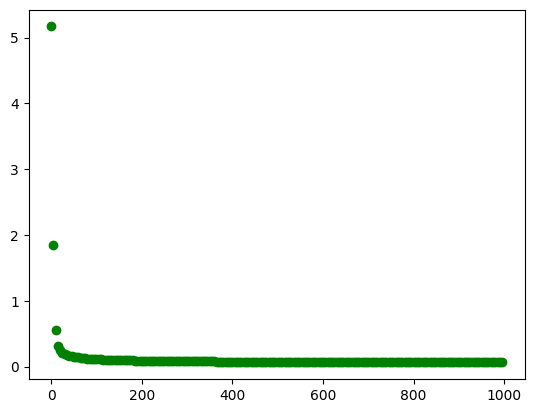

In [9]:
# Train the model on the training data by calling the function 'logistic_regression'
W = logistic_regression(X, y_train, learning_rate, epochs)

In [10]:
# Print the final value of the weight parameters
print(W)

[ 0.59748605 -0.58139667 -0.91084219 -0.5833717   0.00663003 -0.23399063
  0.19740033 -0.92674477 -0.60870282 -0.0293013   0.43072368 -0.96340194
  0.14467402 -0.62066169 -0.68142496 -0.03811121  0.40973194 -0.04644622
  0.1391746   0.21815815  0.446805   -0.99003742 -0.84749328 -0.58961153
 -0.99493365 -0.91253067 -0.21189925 -0.50821372 -1.13693964 -0.67733219
  0.18226825]


In [11]:
# Evaluate the accuracy of the model on the test data
X_test_scaled = X_test_scaled.T
ones = np.ones((1, X_test_scaled.shape[1]))
X_test_scaled = np.append(ones, X_test_scaled, axis=0)

z = np.dot(W, X_test_scaled)
p = sigmoid(z)
y_pred = (p >= 0.5).astype(int)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9912280701754386


In [12]:
from sklearn.metrics import confusion_matrix

# Show the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[42  1]
 [ 0 71]]


In [13]:
features = [
    2.029e01,
    1.434e01,
    1.351e02,
    1.297e03,
    1.003e-01,
    1.328e-01,
    1.980e-01,
    1.043e-01,
    1.809e-01,
    5.883e-02,
    7.572e-01,
    7.813e-01,
    5.438e00,
    9.444e01,
    1.149e-02,
    2.461e-02,
    5.688e-02,
    1.885e-02,
    1.756e-02,
    5.115e-03,
    2.254e01,
    1.667e01,
    1.522e02,
    1.575e03,
    1.374e-01,
    2.050e-01,
    4.000e-01,
    1.625e-01,
    2.364e-01,
    7.678e-02,
]
features_scaled = scaler.transform([features])

features_scaled = features_scaled.T
ones = np.ones((1, features_scaled.shape[1]))
features_scaled = np.append(ones, features_scaled, axis=0)

z = np.dot(W, features_scaled)
p = sigmoid(z)
y_pred = (p >= 0.5).astype(int)

print("Predicted class for the new data point:", y_pred[0])

Predicted class for the new data point: 0
